
___

## Climate Change Impact Analysis and Future Temperature Prediction Using Machine Learning


---

### Project Overview  

Climate change has become one of the most significant environmental challenges affecting ecosystems, economies, and human health worldwide. Rising greenhouse gas emissions, increasing energy consumption, changes in forest cover, and varying weather conditions have contributed to global temperature changes. Accurate temperature prediction can help governments, researchers, and policymakers understand climate trends and develop effective environmental strategies.  

This project aims to analyze climate-related factors and predict the average temperature using machine learning techniques. The project includes data preprocessing, exploratory data analysis (EDA), feature engineering, model development, and performance evaluation. Multiple regression algorithms were compared to identify the most suitable model for temperature prediction.  

### Objectives  

Analyze climate and environmental data to identify factors influencing temperature.  
Perform data cleaning and preprocessing to improve data quality.  
Conduct Exploratory Data Analysis (EDA) to discover patterns and relationships.  
Compare multiple machine learning regression models.  
Evaluate model performance using MAE, MSE, RMSE, and R² Score.  
Select the best-performing model for predicting average temperature.  
Provide meaningful business insights based on the analysis.  

### Dataset Description

**Feature**-Description 
**Year**-Year of observation  
**Month**-Month of observation  
**Country**-Country name  
**Latitude**-Geographic latitude  
**Longitude**-Geographic longitude  
**CO2_Emissions**-Carbon dioxide emissions  
**Methane_Emissions**-Methane emissions  
**NitrousOxide_Emissions**-Nitrous oxide emissions  
**Forest_Area**-Percentage of forest area  
**Renewable_Energy**-Renewable energy usage  
**Population**-Population of the country  
**Energy_Consumption**-Total energy consumption  
**Rainfall**-Annual rainfall  
**Humidity**-Average humidity  
**AverageTemperature**-Average temperature (Target Variable)  

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Load Dataset

In [2]:
df = pd.read_excel(r"C:\Users\LENOVO\Downloads\Climate_Change_RF_High_Performance_Dataset.xlsx")
df

,Year,Month,Country,Latitude,Longitude,CO2_Emissions,Methane_Emissions,NitrousOxide_Emissions,Forest_Area,Renewable_Energy,Population,Energy_Consumption,Rainfall,Humidity,AverageTemperature
0,2010,3,Canada,53.40,-107.01,13.82,145.45,12.43,78.56,89.89,91.52,5255.00,1835.76,79.25,18.81
1,2002,6,Russia,63.31,86.35,7.27,136.24,10.32,38.03,79.13,594.58,1001.24,1739.19,66.45,6.30
2,2024,4,France,44.18,-0.07,14.67,234.85,17.54,16.96,19.99,138.54,7034.08,2780.11,48.01,40.74
3,1995,4,Canada,54.41,-104.64,13.91,248.85,15.87,75.57,50.83,863.24,692.49,1405.99,93.72,11.37
4,1998,1,Germany,54.04,10.15,15.97,200.26,16.95,22.02,35.81,489.59,6771.78,2829.72,74.45,33.11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,2007,2,Mexico,22.74,-103.42,9.54,105.45,8.81,50.48,57.66,1012.98,5322.30,2313.35,63.41,25.36
19996,2010,10,France,44.86,2.94,6.90,138.31,6.24,29.32,48.48,110.09,1953.19,1170.59,91.62,12.23
19997,2024,4,UK,52.60,-1.86,18.80,94.60,17.50,26.05,89.95,563.90,5877.42,2374.95,83.77,32.82
19998,2004,8,France,42.02,3.11,15.33,165.20,16.72,76.79,40.82,627.39,1686.87,498.83,62.26,10.25


### Data Understanding

In [3]:
df.head() 

,Year,Month,Country,Latitude,Longitude,CO2_Emissions,Methane_Emissions,NitrousOxide_Emissions,Forest_Area,Renewable_Energy,Population,Energy_Consumption,Rainfall,Humidity,AverageTemperature
0,2010,3,Canada,53.40,-107.01,13.82,145.45,12.43,78.56,89.89,91.52,5255.00,1835.76,79.25,18.81
1,2002,6,Russia,63.31,86.35,7.27,136.24,10.32,38.03,79.13,594.58,1001.24,1739.19,66.45,6.30
2,2024,4,France,44.18,-0.07,14.67,234.85,17.54,16.96,19.99,138.54,7034.08,2780.11,48.01,40.74
3,1995,4,Canada,54.41,-104.64,13.91,248.85,15.87,75.57,50.83,863.24,692.49,1405.99,93.72,11.37
4,1998,1,Germany,54.04,10.15,15.97,200.26,16.95,22.02,35.81,489.59,6771.78,2829.72,74.45,33.11


In [4]:
df.describe()

,Year,Month,Latitude,Longitude,CO2_Emissions,Methane_Emissions,NitrousOxide_Emissions,Forest_Area,Renewable_Energy,Population,Energy_Consumption,Rainfall,Humidity,AverageTemperature
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,19496.000000,20000.000000,20000.000000,19517.000000,20000.000000,20000.000000,19525.000000,20000.000000,20000.000000
mean,2010.078800,6.544500,26.078676,21.546407,11.021365,164.475256,11.517573,45.000545,47.434509,751.353877,5240.528800,1798.588021,59.980369,25.486959
std,8.933475,3.455042,28.824787,82.899735,5.196999,49.159149,3.759248,20.234478,24.591952,431.973425,2740.799676,978.290857,20.278889,9.985761
min,1995.000000,1.000000,-33.990000,-109.990000,2.010000,80.000000,5.000000,10.000000,5.000000,5.040000,500.790000,100.040000,25.000000,-6.230000
25%,2002.000000,4.000000,-0.542500,-53.272500,6.510000,121.870000,8.260000,27.710000,26.190000,377.787500,2865.817500,952.250000,42.180000,18.010000
50%,2010.000000,7.000000,36.430000,9.995000,11.010000,163.950000,11.540000,45.135000,47.260000,751.765000,5228.215000,1799.890000,59.955000,25.400000
75%,2018.000000,10.000000,49.510000,100.770000,15.530000,207.000000,14.770000,62.490000,68.720000,1122.805000,7612.572500,2647.100000,77.540000,32.900000
max,2025.000000,12.000000,63.990000,142.000000,20.000000,249.990000,18.000000,80.000000,89.990000,1499.990000,9999.870000,3499.860000,95.000000,55.550000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Year                    20000 non-null  int64  
 1   Month                   20000 non-null  int64  
 2   Country                 20000 non-null  object 
 3   Latitude                20000 non-null  float64
 4   Longitude               20000 non-null  float64
 5   CO2_Emissions           20000 non-null  float64
 6   Methane_Emissions       19496 non-null  float64
 7   NitrousOxide_Emissions  20000 non-null  float64
 8   Forest_Area             20000 non-null  float64
 9   Renewable_Energy        19517 non-null  float64
 10  Population              20000 non-null  float64
 11  Energy_Consumption      20000 non-null  float64
 12  Rainfall                19525 non-null  float64
 13  Humidity                20000 non-null  float64
 14  AverageTemperature      20000 non-null

In [6]:
df.shape

(20000, 15)

### Data Cleaning

In [7]:
df.isnull().sum()

Year                        0
Month                       0
Country                     0
Latitude                    0
Longitude                   0
CO2_Emissions               0
Methane_Emissions         504
NitrousOxide_Emissions      0
Forest_Area                 0
Renewable_Energy          483
Population                  0
Energy_Consumption          0
Rainfall                  475
Humidity                    0
AverageTemperature          0
dtype: int64

In [8]:
df.duplicated().sum() 

np.int64(0)

In [9]:
df["Methane_Emissions"] = df["Methane_Emissions"].fillna(
    df["Methane_Emissions"].median())

df["Renewable_Energy"] = df["Renewable_Energy"].fillna(
    df["Renewable_Energy"].median())

df["Rainfall"] = df["Rainfall"].fillna(
    df["Rainfall"].median())

In [10]:
df.isnull().sum()

Year                      0
Month                     0
Country                   0
Latitude                  0
Longitude                 0
CO2_Emissions             0
Methane_Emissions         0
NitrousOxide_Emissions    0
Forest_Area               0
Renewable_Energy          0
Population                0
Energy_Consumption        0
Rainfall                  0
Humidity                  0
AverageTemperature        0
dtype: int64

## Exploratory Data Analysis (EDA)  

EDA was performed to understand the distribution of climate variables and identify relationships affecting temperature prediction.  

### 1.  Country Count Plot

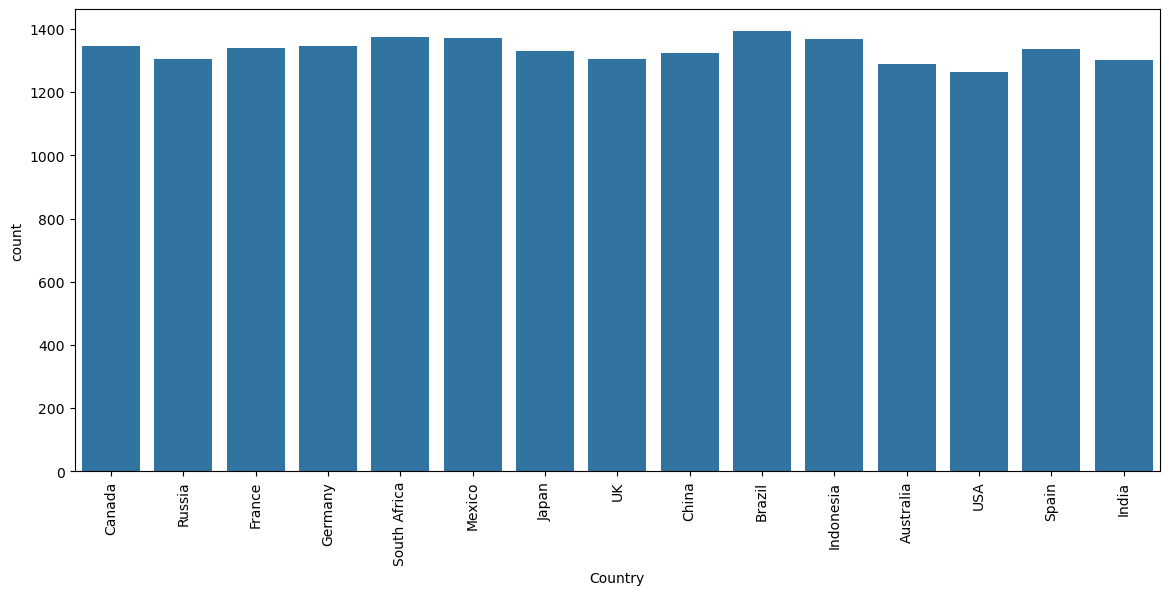

In [11]:
plt.figure(figsize=(14,6))
sns.countplot(data=df,x="Country")
plt.xticks(rotation=90)
plt.show()

**Analysis:**

The count plot indicates the distribution of climate records across different countries, providing a balanced geographical representation for climate change analysis and temperature prediction.  

### 2. Distribution of Average Temperature (Histogram)

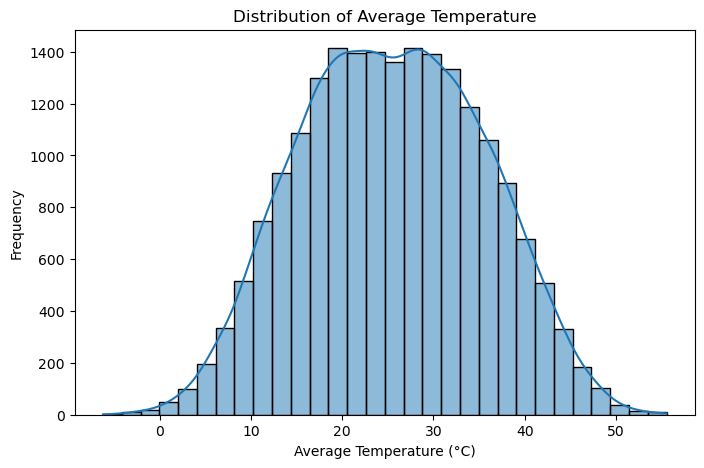

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df["AverageTemperature"], bins=30, kde=True)
plt.title("Distribution of Average Temperature")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Frequency")
plt.show()

**Analysis:**

Shows how average temperatures are distributed across the dataset.  
Helps identify whether the target variable is normally distributed or skewed.  

### 3. Average Temperature by Month (Bar Chart)

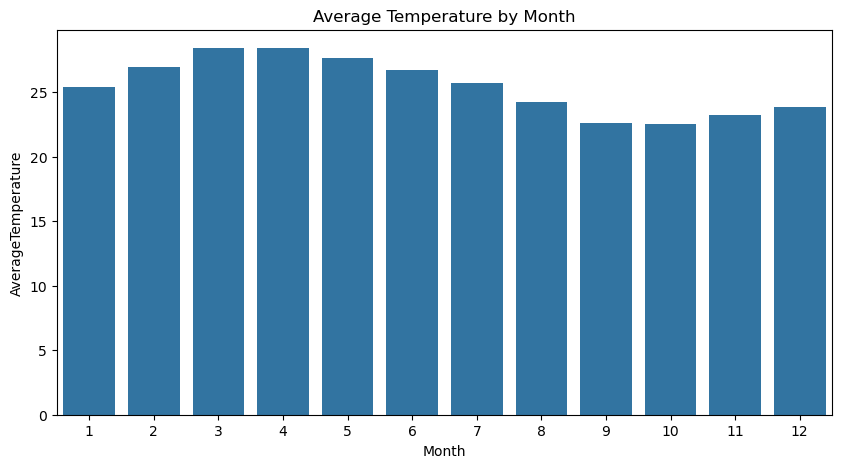

In [13]:
monthly_temp = df.groupby("Month")["AverageTemperature"].mean().reset_index()
plt.figure(figsize=(10,5))
sns.barplot(data=monthly_temp, x="Month", y="AverageTemperature")
plt.title("Average Temperature by Month")
plt.show()

**Analysis:**

Identifies seasonal temperature variations.  
Helps determine the hottest and coolest months.  

### 4. Rainfall Distribution (Box Plot)

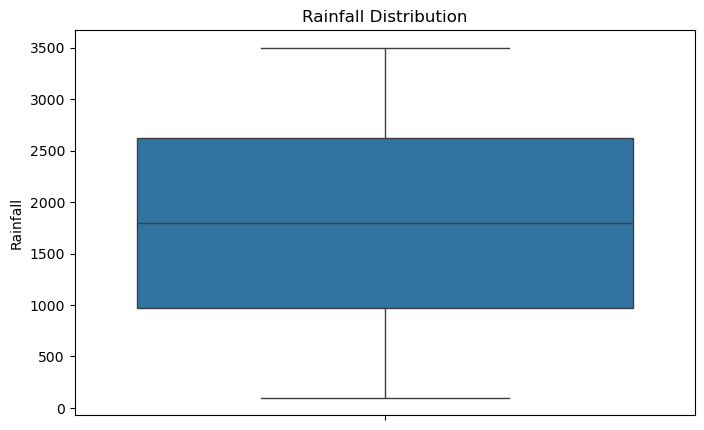

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(y=df["Rainfall"])
plt.title("Rainfall Distribution")
plt.show()

**Analysis:**

Detects outliers in rainfall measurements.  
Shows the spread and variability of rainfall.  

### 5. Forest Area Distribution

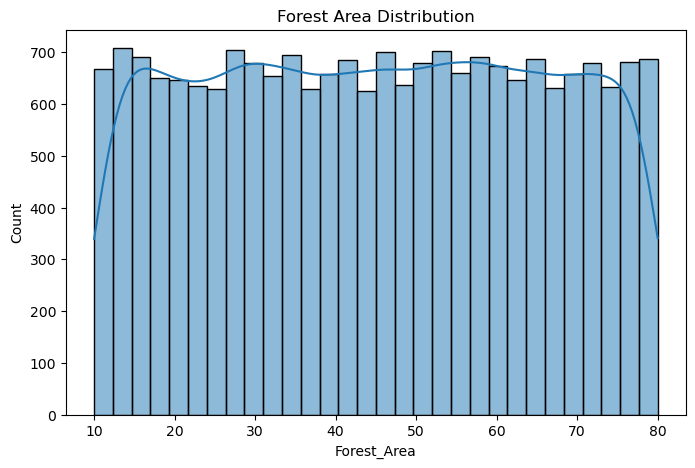

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df["Forest_Area"],bins=30,kde=True)
plt.title("Forest Area Distribution")
plt.show()

**Analysis:**

Shows the distribution of forest area across observations.  
Helps identify whether forest coverage is evenly distributed or skewed.  

### 6. Correlation Heatmap

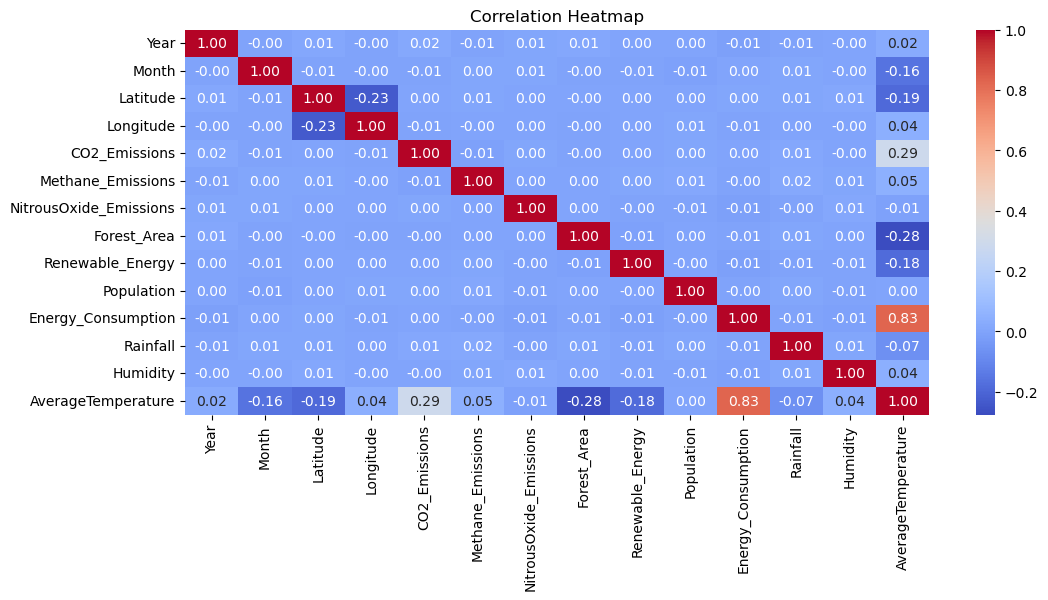

In [16]:
plt.figure(figsize=(12,5))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

**Analysis:**

Displays relationships between all numerical variables.  
Helps identify features strongly correlated with Average Temperature.  

## Machine Learning Models

**The following regression models were trained and evaluated:** 

1.Linear Regression  
2.Decision Tree Regressor  
3.Random Forest Regressor  

**Performance comparison was carried out using:**

1.Mean Absolute Error (MAE)  
2.Mean Squared Error (MSE)  
3.Root Mean Squared Error (RMSE)  
4.R² Score  

In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [18]:
from sklearn.preprocessing import LabelEncoder

country_encoder = LabelEncoder()
month_encoder = LabelEncoder()

df["Country"] = country_encoder.fit_transform(df["Country"])
df["Month"] = month_encoder.fit_transform(df["Month"])

In [19]:
X = df.drop("AverageTemperature", axis=1)

y = df["AverageTemperature"]

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

### Model Building

In [21]:
# Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [22]:
lr = LinearRegression()

In [23]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
pred_lr = lr.predict(X_test)

In [25]:
print("Linear Regression")
print("MAE :", mean_absolute_error(y_test, pred_lr))
print("MSE :", mean_squared_error(y_test, pred_lr))
print("RMSE :", np.sqrt(mean_squared_error(y_test, pred_lr)))
print("R2 Score :", r2_score(y_test, pred_lr))

Linear Regression
MAE : 1.8391947229014542
MSE : 5.243113157685245
RMSE : 2.2897845221079747
R2 Score : 0.9486101296662265


In [26]:
# Decision Tree

from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

In [27]:
dt.fit(X_train, y_train)


,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [28]:
pred_dt = dt.predict(X_test)

In [29]:
print("Decision Tree")
print("MAE :", mean_absolute_error(y_test, pred_dt))
print("MSE :", mean_squared_error(y_test, pred_dt))
print("RMSE :", np.sqrt(mean_squared_error(y_test, pred_dt)))
print("R2 Score :", r2_score(y_test, pred_dt))

Decision Tree
MAE : 2.8057325
MSE : 12.550694575000001
RMSE : 3.542695947297764
R2 Score : 0.8769855718519733


In [30]:
# Random Forest

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)


In [31]:
rf.fit(X_train, y_train)

,n_estimators,500
,criterion,'squared_error'
,max_depth,20
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [32]:
pred_rf = rf.predict(X_test)

In [33]:
print("Random Forest Performance")
print("-"*40)

print("MAE :", mean_absolute_error(y_test, pred_rf))
print("MSE :", mean_squared_error(y_test, pred_rf))
print("RMSE :", np.sqrt(mean_squared_error(y_test, pred_rf)))
print("R2 Score :", r2_score(y_test, pred_rf))

Random Forest Performance
----------------------------------------
MAE : 1.952861273546892
MSE : 5.981406221117036
RMSE : 2.445691358515427
R2 Score : 0.9413738210730253


**Feature Importance (Random Forest)**

Even though Linear Regression is your final model, showing feature importance from Random Forest helps explain which variables are influential.  

In [34]:
importance = pd.DataFrame({'Feature':X.columns,'Importance':rf.feature_importances_}).sort_values(by='Importance',ascending=False)
importance

,Feature,Importance
11,Energy_Consumption,0.611013
5,CO2_Emissions,0.084604
8,Forest_Area,0.075800
3,Latitude,0.052795
9,Renewable_Energy,0.037944
1,Month,0.035742
4,Longitude,0.017778
12,Rainfall,0.014933
6,Methane_Emissions,0.013322
13,Humidity,0.012814


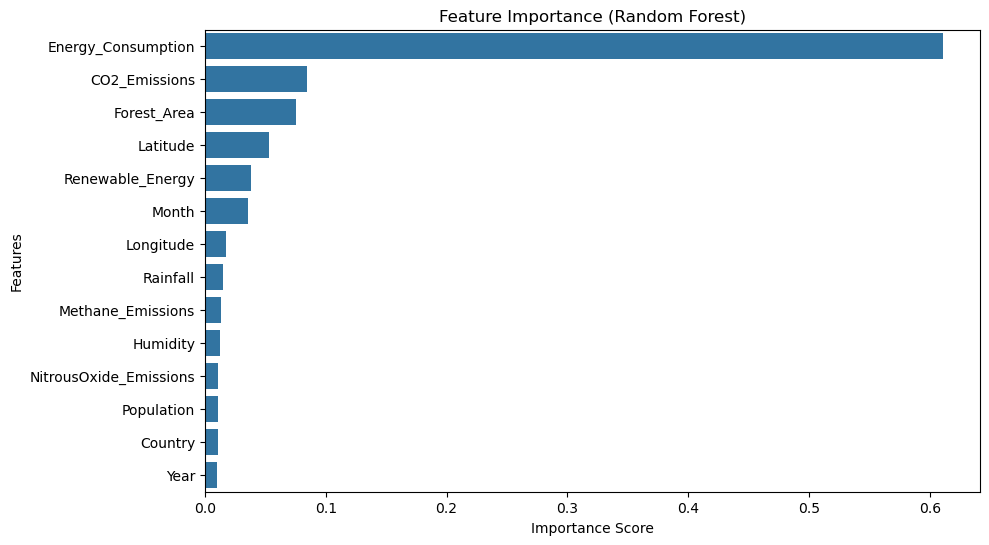

In [35]:
plt.figure(figsize=(10,6))
sns.barplot(data=importance,x="Importance",y="Feature")
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

**Analysis**

The chart ranks the variables according to their contribution to temperature prediction.  
Features with higher importance scores have a greater influence on the model's predictions.  

### Model Comparison

In [36]:
import pandas as pd

results = pd.DataFrame({

'Model':['Linear Regression',
          'Decision Tree',
          'Random Forest'],

'MAE':[mean_absolute_error(y_test,pred_lr),
       mean_absolute_error(y_test,pred_dt),
       mean_absolute_error(y_test,pred_rf)],

'MSE':[mean_squared_error(y_test,pred_lr),
       mean_squared_error(y_test,pred_dt),
       mean_squared_error(y_test,pred_rf)],

'RMSE':[np.sqrt(mean_squared_error(y_test,pred_lr)),
        np.sqrt(mean_squared_error(y_test,pred_dt)),
        np.sqrt(mean_squared_error(y_test,pred_rf))],

'R2 Score':[r2_score(y_test,pred_lr),
            r2_score(y_test,pred_dt),
            r2_score(y_test,pred_rf)]

})

results.sort_values(by='R2 Score',ascending=False)

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,1.839195,5.243113,2.289785,0.948610
2,Random Forest,1.952861,5.981406,2.445691,0.941374
1,Decision Tree,2.805732,12.550695,3.542696,0.876986


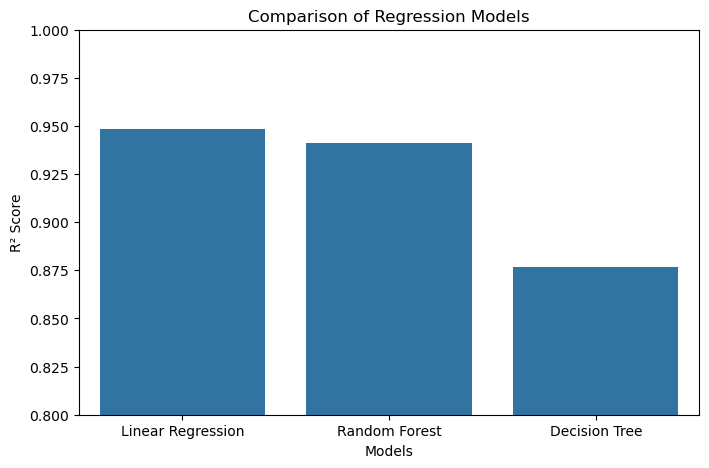

In [37]:
comparison = results.sort_values(by="R2 Score", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(data=comparison,x="Model",y="R2 Score")
plt.title("Comparison of Regression Models")
plt.xlabel("Models")
plt.ylabel("R² Score")
plt.ylim(0.80,1.00)
plt.show()

**Analysis**
  
Linear Regression achieved the highest R² score among all evaluated models.  
Decision Tree showed the lowest predictive performance, while Random Forest performed competitively but did not surpass Linear Regression.  

**Model Validation & Visualization-Actual vs Predicted Plot** 

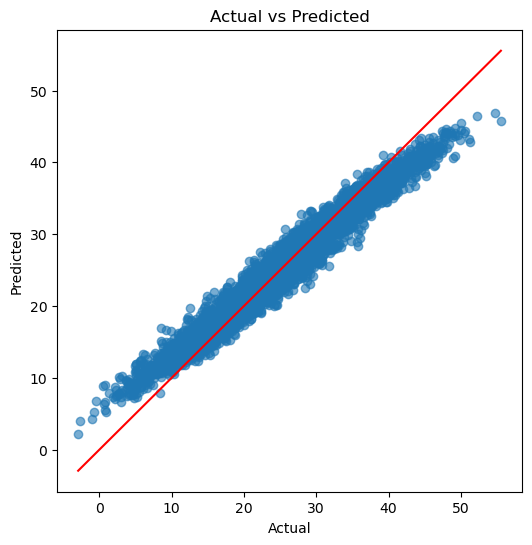

In [38]:
plt.figure(figsize=(6,6))

plt.scatter(y_test,pred_rf,alpha=0.6)

plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'red')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

**Residual Plot**

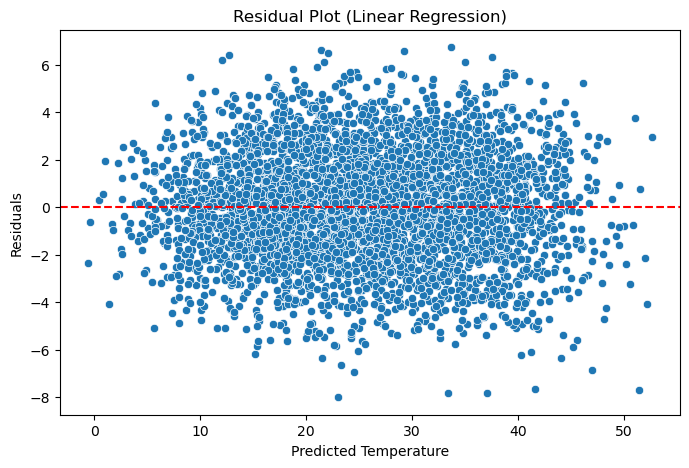

In [39]:
residuals = y_test - pred_lr

plt.figure(figsize=(8,5))
sns.scatterplot(x=pred_lr,y=residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Temperature")
plt.ylabel("Residuals")
plt.title("Residual Plot (Linear Regression)")
plt.show()

After comparison, **Linear Regression** produced the best predictive performance on this dataset.

In [40]:
import joblib

joblib.dump(lr, "model.pkl")
joblib.dump(country_encoder, "country_encoder.pkl")

print("Model and encoder saved successfully!")

Model and encoder saved successfully!



### Conclusion

This project successfully analyzed climate-related factors and predicted average temperature using machine learning regression techniques. After preprocessing and exploratory data analysis, three regression models were evaluated.  

Among all the models, Linear Regression achieved the best performance with an R² Score of 0.9486, explaining approximately 94.86% of the variation in average temperature. It also achieved the lowest MAE and RMSE values, indicating superior predictive accuracy for this dataset.  

The results demonstrate that climate variables such as CO₂ emissions, forest area, energy consumption, rainfall, and humidity significantly influence temperature. This project shows that machine learning can be used as an effective tool for climate analysis and future temperature prediction.  

### Future Scope

Expand the dataset by including additional countries and more recent climate records.  
Incorporate satellite and meteorological data to improve prediction accuracy.  
Develop a real-time temperature prediction dashboard using Power BI or Streamlit.  
Compare additional advanced machine learning models such as XGBoost, LightGBM, and CatBoost.  
Explore deep learning models such as LSTM for long-term climate forecasting.  
Integrate the prediction model with climate monitoring systems for policy planning and environmental management.  

In [41]:
print(X.columns.tolist())

['Year', 'Month', 'Country', 'Latitude', 'Longitude', 'CO2_Emissions', 'Methane_Emissions', 'NitrousOxide_Emissions', 'Forest_Area', 'Renewable_Energy', 'Population', 'Energy_Consumption', 'Rainfall', 'Humidity']
